## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile

url = 'https://drive.upm.es/s/2DDPE2zHw5dbM3G/download'
zip_name = 'dataset.zip'

r = requests.get(url, stream=True)
with open(zip_name, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024):
        f.write(chunk)

if os.path.getsize(zip_name) < 10000:
    print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
else:
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")

    target_file = 'xview_ann_train.json'
    found_path = None

    for root, dirs, files in os.walk("."):
        if target_file in files:
            found_path = os.path.join(root, target_file)
            break

    if found_path:
        print(f"SUCCÈS : Fichier trouvé à : {found_path}")

        import json
        json_file = found_path

        with open(json_file) as ifs:
            json_data = json.load(ifs)
        print("Base de données chargée avec succès !")

    else:
        print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_recognition/xview_ann_train.json
Base de données chargée avec succès !


In [2]:
import tensorflow as tf

# Vérifie la présence de processeurs graphiques
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configuration pour ne pas allouer toute la mémoire d'un coup
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU activé : {len(gpus)} processeur(s) détecté(s)")
    except RuntimeError as e:
        print(e)
else:
    print("GPU non détecté. Activez l'accélérateur dans les réglages du notebook.")

2026-03-02 16:46:17.401610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772469977.606719      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772469977.669411      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772469978.132769      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772469978.132820      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772469978.132823      23 computation_placer.cc:177] computation placer alr

GPU activé : 1 processeur(s) détecté(s)


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [5]:
!pip install rasterio

In [6]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('./xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [7]:
import json

# Load database
json_file = './xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [8]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)
labels = [img.objects[0].category for img in anns]

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [9]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.15, random_state=42, shuffle=True, stratify=labels)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 15934
Number of validation images: 2812


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, RandomFlip, RandomRotation, BatchNormalization
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.optimizers import Nadam

num_classes = len(categories)
input_shape = (114, 114, 3)

def compile_model(model):
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.0005,
        decay_steps=100 * (len(anns_train) // 128)
    )
    model.compile(
        optimizer=Nadam(learning_rate=lr_schedule, weight_decay=1e-4),
        loss=CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
        metrics=['accuracy']
    )
    return model

def create_xview_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    x = RandomFlip("horizontal_and_vertical")(inputs)
    x = RandomRotation(0.5)(x)
    
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    # Un seul return qui englobe la compilation
    return compile_model(Model(inputs, outputs, name="xView_CNN"))

def create_satellite_resnet(input_shape, num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    early_output = base_model.get_layer('conv4_block6_out').output
    
    x = GlobalAveragePooling2D()(early_output)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    
    for layer in model.layers[:-30]:
        layer.trainable = False
    for layer in model.layers[-30:]:
        layer.trainable = True
        
    # Ajout de la compilation avant de retourner le modèle
    return compile_model(model)

# Ajout des arguments requis lors de l'instanciation
models = [
    create_xview_cnn(input_shape, num_classes), 
    create_satellite_resnet(input_shape, num_classes)
]
n_models = len(models)

I0000 00:00:1772470009.523027      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
#from tensorflow.keras.optimizers import Adam
#
## Learning rate is changed to 0.001
#opt = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
#model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
#reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=10, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, early_stop, terminate]

In [ ]:
from skimage.feature import hog
import numpy as np
import tensorflow as tf

import numpy as np
import tensorflow as tf

def generator_images(objs, batch_size, do_shuffle=False, class_weights=None):
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        groups = [objs[i:i+batch_size] for i in range(0, len(objs), batch_size)]
        
        for group in groups:
            images, labels, sample_weights = [], [], []
            for (filename, obj) in group:
                img = load_geoimage(filename)
                img_tensor = tf.convert_to_tensor(img)
                img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
                img_resized = tf.image.resize(tf.convert_to_tensor(crop), [114, 114], method='lanczos3')
                images.append(img_resized.numpy())
                
                cat_idx = list(categories.values()).index(obj.category)
                probabilities = np.zeros(len(categories))
                probabilities[cat_idx] = 1
                labels.append(probabilities)
                
                if class_weights is not None:
                    sample_weights.append(class_weights[cat_idx])
            
            images = np.array(images).astype(np.float32)
            labels = np.array(labels).astype(np.float32)
            
            if class_weights is not None:
                sample_weights = np.array(sample_weights).astype(np.float32)
                yield images, labels, sample_weights
            else:
                yield images, labels

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

print('Calcul des poids de classes...')
y_train_indices = [list(categories.values()).index(obj.category) for _, obj in objs_train]
weights = compute_class_weight('balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weights = dict(enumerate(weights))

class_weights[3] *= 1.5 
class_weights[9] *= 1.5 

batch_size = 128

# On transmet le dictionnaire de poids au générateur d'entraînement
train_generator = generator_images(objs_train, batch_size, do_shuffle=True, class_weights=class_weights)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)

Calcul des poids de classes...


In [15]:
import math
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

epochs = 40
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)

print('Entraînement des modèles')
for i, model in enumerate(models):
    print(f"\n--- Modèle {i+1}/{n_models} ---")
    
    ckpt = ModelCheckpoint(f'model_{i}.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
    
    # L'argument class_weight a été supprimé ici car pris en charge par train_generator
    model.fit(
        train_generator, 
        steps_per_epoch=train_steps, 
        validation_data=valid_generator, 
        validation_steps=valid_steps, 
        epochs=epochs,
        callbacks=[ckpt, EarlyStopping(patience=15, restore_best_weights=True)], 
        verbose=1
    )

Entraînement des modèles

--- Modèle 1/2 ---
Epoch 1/40


I0000 00:00:1772470020.028405      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.1392 - loss: 0.5514
Epoch 1: val_accuracy improved from -inf to 0.27347, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 130s 986ms/step - accuracy: 0.1394 - loss: 0.5511 - val_accuracy: 0.2735 - val_loss: 0.4312
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.2200 - loss: 0.4470
Epoch 2: val_accuracy improved from 0.27347 to 0.31188, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 118s 950ms/step - accuracy: 0.2201 - loss: 0.4470 - val_accuracy: 0.3119 - val_loss: 0.3982
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.2771 - loss: 0.4123
Epoch 3: val_accuracy improved from 0.31188 to 0.34459, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 119s 959ms/step - accuracy: 0.2771 - loss: 0.4122 - val_accuracy: 0.3446 - val_loss: 0.3615
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.3000 - loss: 0.3792
Epoch 4: val_accuracy improved from 0.344

I0000 00:00:1772474476.043545      71 service.cc:152] XLA service 0x7bd2a0332690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772474476.043625      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  2/125 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.0527 - loss: 0.6985  

I0000 00:00:1772474485.555115      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.1193 - loss: 0.5927

2026-03-02 18:03:33.426085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 18:03:34.561758: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.21230, saving model to model_1.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.1196 - loss: 0.5923 - val_accuracy: 0.2123 - val_loss: 0.4758
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.2132 - loss: 0.4554
Epoch 2: val_accuracy improved from 0.21230 to 0.21266, saving model to model_1.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 113s 908ms/step - accuracy: 0.2134 - loss: 0.4553 - val_accuracy: 0.2127 - val_loss: 0.6551
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.2786 - loss: 0.3957
Epoch 3: val_accuracy improved from 0.21266 to 0.22226, saving model to model_1.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 115s 924ms/step - accuracy: 0.2787 - loss: 0.3956 - val_accuracy: 0.2223 - val_loss: 0.6288
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.3180 - loss: 0.3719
Epoch 4: val_accuracy did not improve from 0.22226
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 907ms/step - accuracy: 0.3181 - los

#### Validation
Compute validation metrics.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

y_true, y_pred = [], []
all_images = []
temp_true_labels = []

print("Chargement des données de validation...")
for ann in anns_valid:
    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [114, 114], method='lanczos3')

    for obj_pred in ann.objects:
        all_images.append(image_resized.numpy())
        temp_true_labels.append(obj_pred.category)

if all_images:
    X_valid = np.array(all_images)
    print(f"Lancement de la prédiction sur {len(X_valid)} objets...")

    all_predictions = np.mean([
        model.predict(X_valid, batch_size=64, verbose=1) 
        for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i in range(len(all_predictions)):
        pred_idx = np.argmax(all_predictions[i])
        
        # Conversion du vrai label en index pour s'aligner avec la prédiction
        true_idx = category_names.index(temp_true_labels[i])
        
        y_true.append(true_idx)
        y_pred.append(pred_idx)

Chargement des données de validation...
Lancement de la prédiction sur 2812 objets...
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step


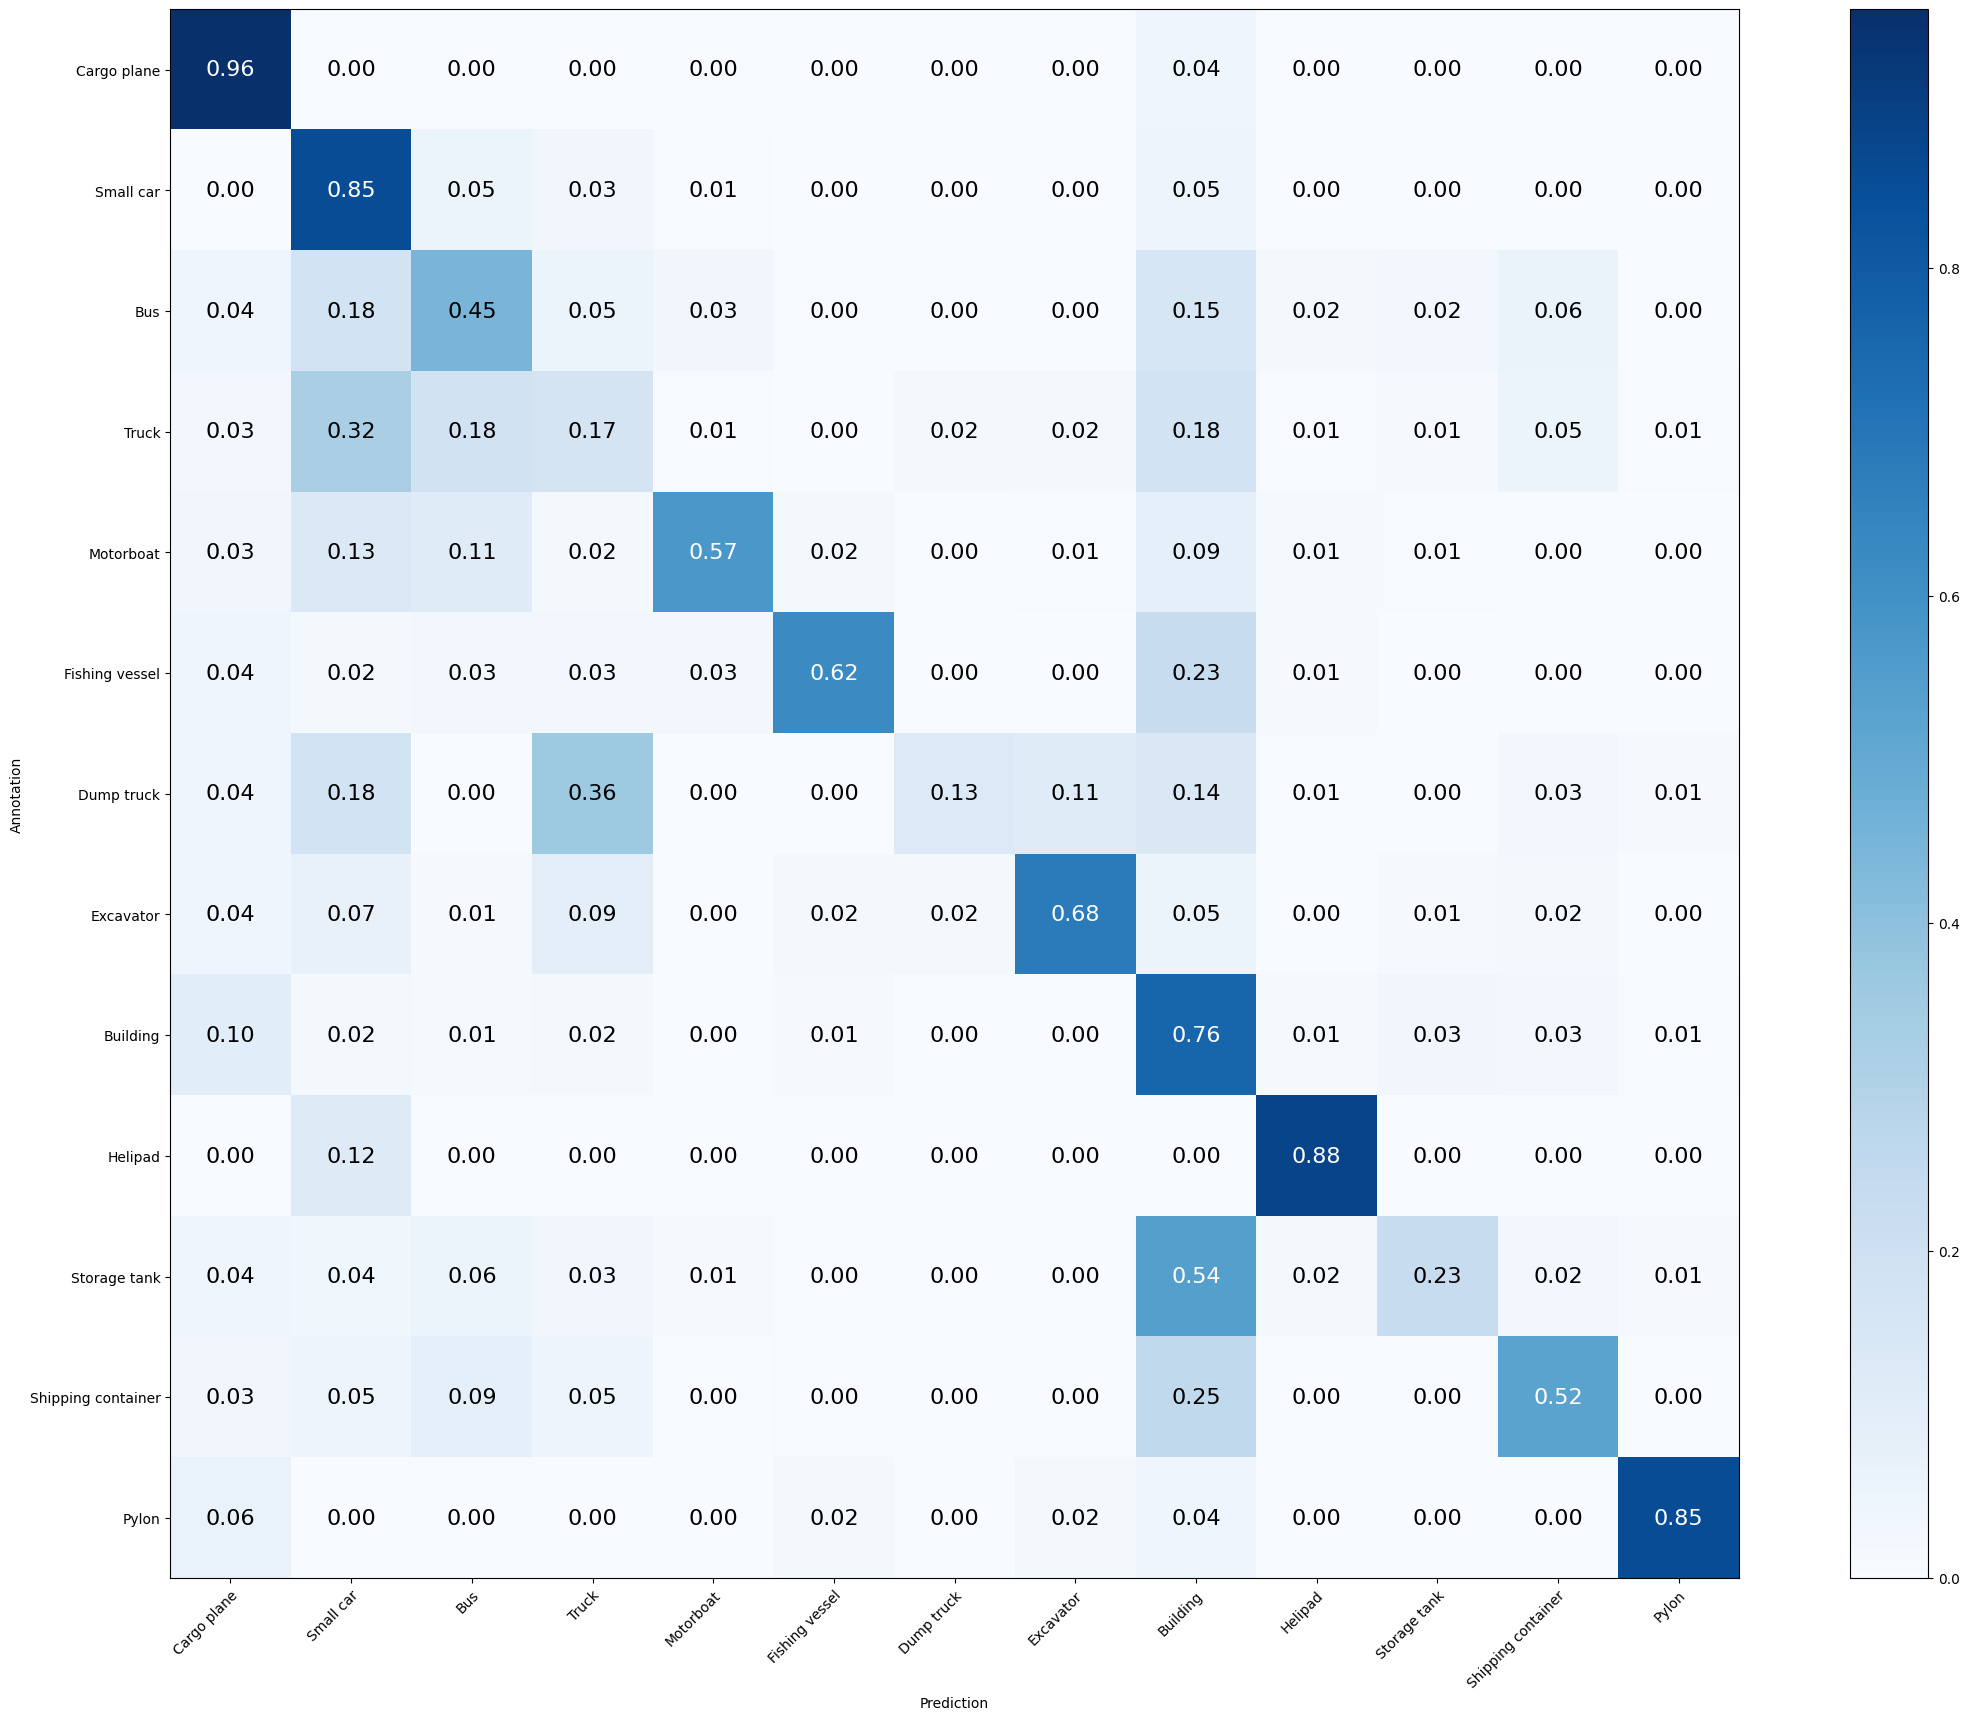

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
draw_confusion_matrix(cm, categories)

In [19]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 56.437%
Mean Recall: 59.033%
Mean Precision: 61.051%
> Cargo plane: Recall: 95.789% Precision: 43.541% Specificity: 95.657% Dice: 59.868%
> Small car: Recall: 85.170% Precision: 63.150% Specificity: 89.278% Dice: 72.526%
> Bus: Recall: 44.528% Precision: 44.195% Specificity: 94.150% Dice: 44.361%
> Truck: Recall: 16.867% Precision: 28.718% Specificity: 94.395% Dice: 21.252%
> Motorboat: Recall: 57.500% Precision: 83.636% Specificity: 99.321% Dice: 68.148%
> Fishing vessel: Recall: 62.264% Precision: 80.488% Specificity: 99.409% Dice: 70.213%
> Dump truck: Recall: 12.973% Precision: 75.000% Specificity: 99.695% Dice: 22.120%
> Excavator: Recall: 67.797% Precision: 71.429% Specificity: 98.812% Dice: 69.565%
> Building: Recall: 76.067% Precision: 52.163% Specificity: 83.458% Dice: 61.887%
> Helipad: Recall: 88.235% Precision: 40.541% Specificity: 99.213% Dice: 55.556%
> Storage tank: Recall: 22.727% Precision: 62.500% Specificity: 98.843% Dice: 33.333%
> Shipping container:

#### Testing
Try to improve the results provided in the competition.

In [20]:
import os
import numpy as np

anns = []
root_dir = './xview_recognition/'
test_dir = os.path.join(root_dir, 'xview_test')
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        rel_dir = os.path.relpath(dirpath, root_dir)
        clean_filename = os.path.join(rel_dir, filename)
        image = GenericImage(clean_filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = os.path.basename(dirpath)
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [ ]:
import numpy as np
import tensorflow as tf

predictions_data = {"images": {}, "annotations": {}}
all_test_images = []
metadata = [] 
ann_id = 0

print("Préparation des images de test...")
for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [114, 114], method='lanczos3')
    img_final = image_resized.numpy()

    for obj_pred in ann.objects:
        all_test_images.append(img_final)
        metadata.append({
            "image_id": ann.filename.split('/')[-1],
            "bbox": [int(x) for x in obj_pred.bb]
        })

if all_test_images:
    X_test = np.array(all_test_images)
    print(f"Prédiction en cours sur {len(X_test)} détections...")

    # Calcul de la moyenne des prédictions des 3 modèles
    all_preds = np.mean([
        model.predict({"img_input": X_test}, batch_size=128, verbose=1)
        for model in models
    ], axis=0)

    category_names = list(categories.values())

    for i, pred in enumerate(all_preds):
        pred_category = category_names[np.argmax(pred)]

        predictions_data["annotations"][ann_id] = {
            "image_id": metadata[i]["image_id"],
            "category_id": pred_category,
            "bbox": metadata[i]["bbox"]
        }
        ann_id += 1

print("Test terminé.")

Préparation des images de test...
Prédiction en cours sur 2365 détections...


ValueError: Missing data for input "input_layer". You passed a data dictionary with keys ['img_input']. Expected the following keys: ['input_layer']

In [ ]:
#for i, model in enumerate(models):
#    model.load_weights(f'model_{i}.keras')

In [ ]:
import json
with open('prediction.json', 'w') as f:
    json.dump(predictions_data, f)